#  1. Segmentation
Segmentation은 컴퓨터 비전에서 이미지나 영상을 픽셀 단위로 분할하여 각 영역이 무엇을 나타내는지 구분하는 기술입니다. 이는 크게 Semantic Segmentation과 Instance Segmentation으로 나뉘는데, Semantic Segmentation은 같은 종류의 객체를 동일한 클래스로 분류하는 반면, Instance Segmentation은 같은 클래스 내에서도 개별 객체를 구분합니다. 이를 통해 의료 영상 분석, 자율주행, 위성 이미지 처리 등 다양한 분야에서 정밀한 객체 인식을 수행할 수 있습니다. Segmentation 모델로는 U-Net, DeepLab, Mask R-CNN 등이 널리 사용됩니다.

![Segmentation02](./images/Segmentation02.png)

# **3.Detection이 문제 정의에 적합한지 검토**
- Bounding Box로 감싸는 Object Detection 방식은 이안류처럼 형태가 불규칙하고 경계가 명확하지 않은 영역일 경우 Segmentation이 더 적합할 수도 있음

icrawler

# **2. 스타벅스 데이터셋**


### COCO JSON
- images: 이미지 ID, 파일명, width, height
- annotations: 객체의 category, polygon, bbox 등
- categories: 클래스 ID와 이름

In [1]:
import json
import random
import shutil
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import ultralytics
import yaml

from ultralytics import YOLO

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
SOURCE_DIR = DATA_ROOT / "starbucks"
YOLO_ROOT = DATA_ROOT / "Starbucks_YOLO"
COCO_JSON = SOURCE_DIR / "instances_default.json"

print("PROJECT_ROOT: ", PROJECT_ROOT)
print("SOURCE_DIR: ", SOURCE_DIR)
print("YOLO_ROOT: ", YOLO_ROOT)
print("COCO_JSON: ", COCO_JSON)

PROJECT_ROOT:  c:\heeseung\11_CV
SOURCE_DIR:  c:\heeseung\11_CV\data\starbucks
YOLO_ROOT:  c:\heeseung\11_CV\data\Starbucks_YOLO
COCO_JSON:  c:\heeseung\11_CV\data\starbucks\instances_default.json


In [3]:
with COCO_JSON.open("r", encoding="utf-8") as f:
    coco_data = json.load(f)

coco_data

{'licenses': [{'name': '', 'id': 0, 'url': ''}],
 'info': {'contributor': '',
  'date_created': '',
  'description': '',
  'url': '',
  'version': '',
  'year': ''},
 'categories': [{'id': 1, 'name': 'logo', 'supercategory': ''},
  {'id': 2, 'name': 'text', 'supercategory': ''}],
 'images': [{'id': 1,
   'width': 1024,
   'height': 682,
   'file_name': '000001.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 2,
   'width': 885,
   'height': 960,
   'file_name': '000002.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 3,
   'width': 1600,
   'height': 1155,
   'file_name': '000003.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 4,
   'width': 1300,
   'height': 956,
   'file_name': '000004.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 5,
   'width': 900,
   'height': 1200,
   'file_name': '000005.j

In [4]:
# category ID가 반드시 연속이라는 보장이 없음
categories = sorted(coco_data['categories'], key = lambda x: x['id'])

COCO_ID_TO_YOLO_ID = {
    category['id']: yolo_id for yolo_id, category in enumerate(categories)
}

CLASS_NAMES = [category['name'] for category in categories]

print('이미지 수: ', len(coco_data['images']))
print('Annotation 수: ', len(coco_data['annotations']))
print('클래스 : ', CLASS_NAMES)
print('ID 매핑: ', COCO_ID_TO_YOLO_ID)

이미지 수:  612
Annotation 수:  1296
클래스 :  ['logo', 'text']
ID 매핑:  {1: 0, 2: 1}


### 이미지와 Annotation 확인
- JSON에 등록된 이미지가 실제 폴더에 모두 존재하는지 확인
- 클래스별 annotation 수를 확인하면 특정 클래스가 지나치게 적은지도 확인할 수 있음

In [5]:
image_info_by_id = {image_info['id']: image_info for image_info in coco_data['images']}

missing_images = []

for image_info in coco_data['images']:
    image_path = SOURCE_DIR / image_info['file_name']
    if not image_path.exists():
        missing_images.append(image_info['file_name'])


class_counts = Counter(
    COCO_ID_TO_YOLO_ID[ann['category_id']] for ann in coco_data['annotations']
    if ann['category_id'] in COCO_ID_TO_YOLO_ID
)

print("누락 이미지 수: ", len(missing_images))

if missing_images:
    print(missing_images)

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id}: {class_name} > {class_counts[class_id]} annotations")

누락 이미지 수:  0
0: logo > 933 annotations
1: text > 363 annotations


### COCO Polygon Annotation 시각화
- COCO Polygon Annotation의 좌표

```
[x1, y1, x2, y2, x3, y3, ...]
최소 3개의 점을 연결하여 객체 외곽을 표현
```

In [6]:
def load_rgb_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'이미지를 읽을 수 없습니다: {image_path}')
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [7]:
def visualize_coco_annotation(image_id: int):
    image_info = image_info_by_id.get(image_id)
    if image_info is None:
        raise ValueError(f'존재하지 않는 image_id입니다: {image_id}')

    image = load_rgb_image(SOURCE_DIR / image_info['file_name']).copy()

    for ann in coco_data['annotations']:
        if ann['image_id'] != image_id:
            continue

        class_id = COCO_ID_TO_YOLO_ID[ann['category_id']]
        class_name = CLASS_NAMES[class_id]

        for polygon in ann.get('segmentation', []):
            if not isinstance(polygon, list) or len(polygon) < 6:
                continue

            points = np.array(polygon, dtype=np.float32).reshape(-1, 2).astype(np.int32)  # 묶을건데 몇 개인지 몰라 그럼 -1 그리고 2개씩 묶어라

            cv2.polylines(image, [points], True, (0, 255, 0), 2)

            x, y = points[0]
            cv2.putText(image, class_name, (int(x), max(20, int(y) - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'COCO Annotation - {image_info['file_name']}')
    plt.show()

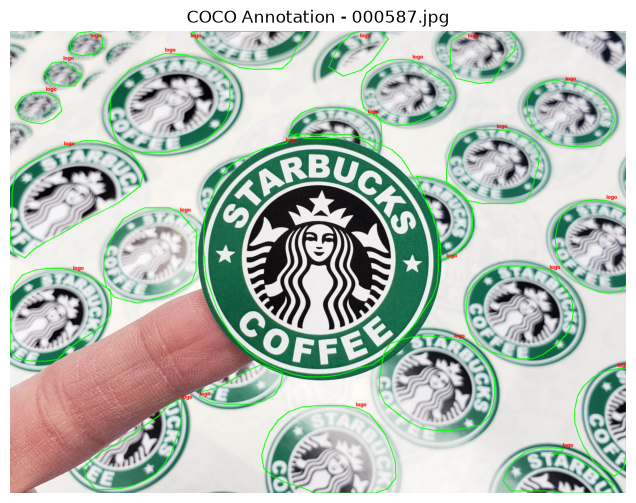

In [8]:
visualize_coco_annotation(image_id=524)

### COCO > YOLO Segmentation 변환

YOLO Segmentation 라벨
```
class_id x1, y1, x2, y2, ...
```
좌표는 픽셀 값이 아니라 0 ~ 1 사이로 정규화
- x_norm = x/image_width
- y_norm = y/image_height

In [9]:
def coco_polygon_to_yolo_line(class_id, polygon, image_width, image_height):
    if not isinstance(polygon, list) or len(polygon) < 6:
        return None

    if len(polygon) % 2!= 0:
        return None

    normalized_values = []

    for i in range(0, len(polygon), 2):
        x = polygon[i]
        y = polygon[i + 1]
        x_norm = x / image_width
        y_norm = y / image_height

        x_norm = min(max(x_norm, 0.0), 1.0)
        y_norm = min(max(y_norm, 0.0), 1.0)
        normalized_values.extend([x_norm, y_norm])

    coordinates = " ".join(f"{value:.6f}" for value in normalized_values)
    return f'{class_id} {coordinates}'

### train / val / test 분할

In [10]:
SEED = 2006
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2

random.seed(SEED)

all_images = [image_info for image_info in coco_data['images'] 
                if(SOURCE_DIR / image_info['file_name']).exists()]

random.shuffle(all_images)
num_images = len(all_images)
num_train = int(num_images * TRAIN_RATIO)
num_val = int(num_images * VAL_RATIO)

train_images = all_images[:num_train]
val_images = all_images[num_train:num_train+num_val]
test_images = all_images[num_train+num_val:]

print('전체: ', num_images)
print('train: ', len(train_images))
print('val: ', len(val_images))
print('test: ', len(test_images))

전체:  612
train:  367
val:  122
test:  123


### YOLO 폴더 구조 생성

- YOLO의 명확한 구조는 이미지와 라벨을 분리하는 방식
- 예) images/train/starbucks11.jpg > label/train/starbucks11.txt

In [11]:
def prepare_yolo_split(split_name, split_images):
    image_output_dir = YOLO_ROOT / "images" / split_name
    label_output_dir = YOLO_ROOT / "labels" / split_name

    image_output_dir.mkdir(parents=True, exist_ok=True)
    label_output_dir.mkdir(parents=True, exist_ok=True)

    # 재실행 할 때 과거 파일이 남아 섞이는 것을 방지
    for old_file in image_output_dir.iterdir():
        if old_file.is_file():
            old_file.unlink()

    for old_file in label_output_dir.iterdir():
            if old_file.is_file():
                old_file.unlink()

    annotations_by_image = {}

    for ann in coco_data['annotations']:
        annotations_by_image.setdefault(ann['image_id'], []).append(ann)

    for image_info in split_images:
        image_id = image_info['id']
        image_width = image_info['width']
        image_height = image_info['height']
        file_name = image_info['file_name']

        shutil.copy2(SOURCE_DIR / file_name, image_output_dir / file_name)

        yolo_lines = []

        for ann in annotations_by_image.get(image_id, []):
            coco_category_id = ann['category_id']
            if coco_category_id not in COCO_ID_TO_YOLO_ID:
                continue
            class_id = COCO_ID_TO_YOLO_ID[coco_category_id]

            segmentation = ann.get('segmentation', [])

            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                yolo_line = coco_polygon_to_yolo_line(
                    class_id, polygon, image_width, image_height
                )
                if yolo_line is not None:
                    yolo_lines.append(yolo_line)

        label_path = label_output_dir / f'{Path(file_name).stem}.txt'
        if yolo_lines:
            label_path.write_text("\n".join(yolo_lines), encoding='utf-8')

In [12]:
prepare_yolo_split("train", train_images)
prepare_yolo_split("val", val_images)
prepare_yolo_split("test", test_images)
print("COCO > YOLO Segmentation 변경 완료")

COCO > YOLO Segmentation 변경 완료


### YOLO txt 라벨 다시 시각화
- COCO JSON이 아니라 변환된 YOLO txt를 읽어서 polygon을 그림

In [18]:
def visualize_yolo_label(split_name, image_name):
    image_path = YOLO_ROOT / "images" / split_name / image_name
    label_path = YOLO_ROOT / "labels" / split_name / f"{Path(image_name).stem}.txt"

    image = load_rgb_image(image_path).copy()
    height, width = image.shape[:2]

    if not label_path.exists():
        raise FileNotFoundError(f'라벨이 없습니다: {label_path}')

    for line in label_path.read_text(encoding="utf-8").splitlines():
        values = line.split()
        class_id = int(values[0])
        points = np.array(list(map(float, values[1:])), dtype=np.float32).reshape(-1, 2)
        points[:, 0] *= width
        points[:, 1] *= height
        points = points.astype(np.int32)

        cv2.polylines(image, [points], True, (0, 255, 0), 2)

        x, y = points[0]
        cv2.putText(image, CLASS_NAMES[class_id], (int(x), max(20, int(y) - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"COCO Annotation - {image_info['file_name']}")
        plt.show()

확인 이미지:  000344.jpg


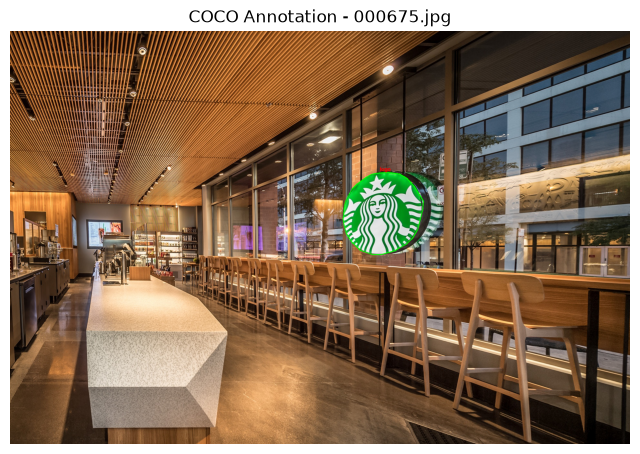

In [23]:
sample_train_image = train_images[300]['file_name']
print("확인 이미지: ", sample_train_image)

visualize_yolo_label("train", sample_train_image)

### YOLO 데이터셋 YAML 생성
Class ID
- 0: logo
- 1: text

In [25]:
yaml_data = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        class_id: class_name for class_id, class_name in enumerate(CLASS_NAMES)
    }
}

YAML_PATH = YOLO_ROOT / "starbucks.yaml"

with YAML_PATH.open("w", encoding = "utf-8") as f:
    yaml.safe_dump(yaml_data, f, allow_unicode = True, sort_keys = False)

print(YAML_PATH.read_text(encoding="utf-8"))

path: C:\heeseung\11_CV\data\Starbucks_YOLO
train: images/train
val: images/val
test: images/test
names:
  0: logo
  1: text



In [26]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [ ]:
# import yaml
# from ultralytics import YOLO

In [15]:
# custom_voc_yaml = YOLO_ROOT / "yolo_segementation02.yaml"

# data_config = {
#     "path": str(YOLO_ROOT.resolve()),
#     "train": "images/train",
#     "val": "images/val",
#     "test": "images/test",
#     "names": {i: name for i, name in enumerate()}
# }

# with open(custom_voc_yaml, "w", encoding="utf-8") as f:
#     yaml.safe_dump(data_config, f, allow_unicode=True, sort_keys=False) # 알파벳 순으로 정렬할 필요가 없어서 False

# print("생성된 YAML 경로: ", custom_voc_yaml)
# print(custom_voc_yaml.read_text(encoding='utf-8'))

# **3. YOLO11 Segmentation 모델**

In [27]:
model = YOLO("yolo11s-seg.pt")
print("Model task: ", model.task)

Model task:  segment


In [28]:
train_results = model.train(
    data = str(YAML_PATH),
    epochs = 50,
    imgsz = 640,
    batch = 4,
    device = DEVICE,
    workers = 0,
    seed = SEED,
    patience = 20,
    name = "starbucks_yolo11s_seg",
    exist_ok= True
)

New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.143  Python-3.12.7 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\heeseung\11_CV\data\Starbucks_YOLO\starbucks.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

이건 파인튜닝임 전이학습의 파인튜닝
모델을 가져와서 추가적으로 학습을 하는거임 이걸 파인튜닝

In [31]:
RUN_DIR = PROJECT_ROOT / "runs" / "segment" /"starbucks_yolo11s_seg"
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"
print("best.pt: ", BEST_MODEL_PATH)

best.pt:  c:\heeseung\11_CV\runs\segment\starbucks_yolo11s_seg\weights\best.pt


In [32]:
# 일반 pretrained 모델이 아니라 Starbucks 데이터로 find-tuning된 모델을 불러옴
best_model = YOLO(str(BEST_MODEL_PATH))
print("Task: ", best_model.task)
print("Classes: ", best_model.names)

Task:  segment
Classes:  {0: 'logo', 1: 'text'}


### Validation 성능 평가
Segmentation 모델은 Box와 Mask 성능을 따로 봄
- metrics.box: Bounding Box 기준
- metrics.seg: Segmentation Mask 기준

In [33]:
metrics = best_model.val(
    data = str(YAML_PATH),
    split = "val",
    imgsz = 640,
    device = DEVICE
)

YOLO11s-seg summary (fused): 113 layers, 10,067,590 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1831.61099.8 MB/s, size: 173.6 KB)
val: Scanning C:\heeseung\11_CV\data\Starbucks_YOLO\labels\val.cache... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.9s/it 15.4s2.3s
                   all        122        285      0.824      0.704      0.755      0.535      0.811      0.697      0.734       0.49
                  logo        111        208      0.923      0.856      0.923       0.74      0.927      0.861      0.928      0.717
                  text         58         77      0.726      0.551      0.588       0.33      0.694      0.532       0.54      0.263
Speed: 2.7ms preprocess, 106.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\heeseung\

In [34]:
print("Box mAP50: ", metrics.box.map50)
print("Box mAP50-95: ", metrics.box.map)
print("Mask mAP50: ", metrics.seg.map50)
print("Mask mAP50-95: ", metrics.box.map)


Box mAP50:  0.7554615513710304
Box mAP50-95:  0.5349881116253551
Mask mAP50:  0.733799495064002
Mask mAP50-95:  0.5349881116253551


### Segmentation 추론
- result.boxes.xyxy: Bounding Box 좌표
- result.boxes.cls: class ID
- result.boxes.conf: confidence score
- result.masks.xy: polygon 좌표
- result.masks.data: mask tensor

In [35]:
TEST_IMAGE_DIR = YOLO_ROOT / "images" / "test"

predict_results = best_model.predict(
    source=str(TEST_IMAGE_DIR),
    imgsz=640,
    conf=0.30,
    device=DEVICE,
    retina_masks=True,
    save=True,
    name="starbucks_yolo11s_set_predict",
    exist_ok=True
)


image 1/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000006.jpg: 640x480 1 logo, 78.0ms
image 2/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000009.jpg: 480x640 1 logo, 103.1ms
image 3/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000028.jpg: 640x448 1 text, 94.5ms
image 4/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000029.jpg: 480x640 1 logo, 143.6ms
image 5/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000039.jpg: 480x640 3 logos, 4 texts, 93.4ms
image 6/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000046.jpg: 416x640 1 logo, 87.7ms
image 7/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000047.jpg: 384x640 1 logo, 88.2ms
image 8/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000052.jpg: 640x416 1 logo, 99.1ms
image 9/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000054.jpg: 448x640 2 logos, 98.4ms
image 10/123 c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000056.jpg: 384x640 2 logos, 1 text, 76.1ms
image 

In [36]:
for result in predict_results[:3]:
    print("=" * 70)
    print("image:", result.path)

    if result.boxes is not None:
        print("classes    :", result.boxes.cls.cpu().tolist())
        print("confidence :", result.boxes.conf.cpu().tolist())
        print("boxes xyxy :")
        print(result.boxes.xyxy.cpu().numpy())

    if result.masks is not None:
        print("mask tensor shape:", tuple(result.masks.data.shape))
        print("polygon 개수     :", len(result.masks.xy))
    else:
        print("검출된 segmentation mask가 없습니다.")

image: c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000006.jpg
classes    : [0.0]
confidence : [0.9505711793899536]
boxes xyxy :
[[     284.22      466.05      712.09      897.92]]
mask tensor shape: (1, 1333, 1000)
polygon 개수     : 1
image: c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000009.jpg
classes    : [0.0]
confidence : [0.6563680171966553]
boxes xyxy :
[[     454.37      112.42      919.06       571.8]]
mask tensor shape: (1, 879, 1200)
polygon 개수     : 1
image: c:\heeseung\11_CV\data\Starbucks_YOLO\images\test\000028.jpg
classes    : [1.0]
confidence : [0.8698916435241699]
boxes xyxy :
[[     460.86      2571.4      1857.6      3059.4]]
mask tensor shape: (1, 4347, 3000)
polygon 개수     : 1


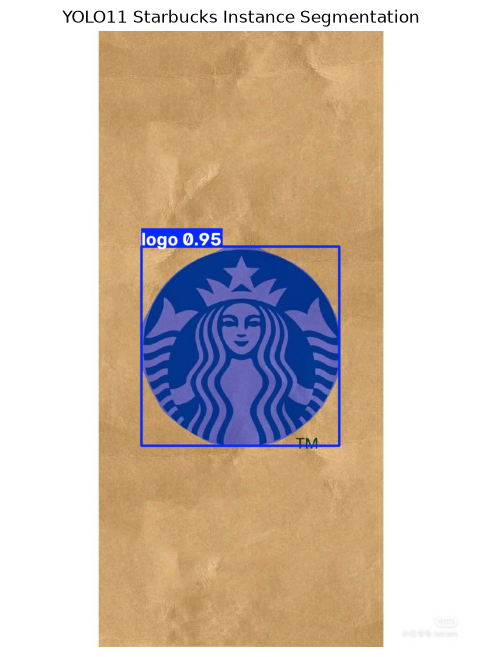

In [37]:
if not predict_results:
    raise RuntimeError("추론 결과가 없습니다.")

result = predict_results[0]

plotted_bgr = result.plot()
plotted_rgb = cv2.cvtColor(
    plotted_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(plotted_rgb)
plt.axis("off")
plt.title("YOLO11 Starbucks Instance Segmentation")
plt.show()